In [ ]:
# ---------- STEP 1: Load Data ----------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
# parse_dates converts FL_DATE from text to an actual datetime object
# so we can group by month/year/day-of-week later
df = pd.read_csv('flights_cleaned.csv', parse_dates=['FL_DATE'])
print(df.shape)
df.head()

(35799, 52)


,FL_DATE,AIRLINE,AIRLINE_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,...,TOTAL_GROUND_TIME,EFFICIENCY_RATIO,IS_PEAK_SEASON,DEP_TIME_OF_DAY,AIRLINE_ENC,ORIGIN_ENC,DEST_ENC,DEP_TIME_OF_DAY_ENC,DELAY_SEVERITY_CAT_ENC,CANCELLATION_CODE_ENC
0,2019-01-09,United Air Lines Inc.,UA,1562,FLL,"Fort Lauderdale, Fl",EWR,"Newark, Nj",1155,1151,...,23.0,0.946,0,Morning,17.0,131.0,123.0,2.0,3.0,2.0
1,2022-11-19,Delta Air Lines Inc.,DL,1149,MSP,"Minneapolis, Mn",SEA,"Seattle, Wa",2120,2114,...,47.0,1.004,1,Night,3.0,247.0,323.0,3.0,3.0,2.0
2,2022-07-22,United Air Lines Inc.,UA,459,DEN,"Denver, Co",MSP,"Minneapolis, Mn",954,1000,...,25.0,0.949,1,Morning,17.0,99.0,247.0,2.0,3.0,2.0
3,2023-03-06,Delta Air Lines Inc.,DL,2295,MSP,"Minneapolis, Mn",SFO,"San Francisco, Ca",1609,1608,...,36.0,1.096,0,Afternoon,3.0,247.0,325.0,0.0,1.0,2.0
4,2020-02-23,Spirit Air Lines,NK,407,MCO,"Orlando, Fl",DFW,"Dallas/Fort Worth, Tx",1840,1838,...,29.0,1.006,0,Evening,16.0,223.0,100.0,1.0,3.0,2.0


In [ ]:
# ---------- STEP 2: Baseline Statistics ----------
# Why: before making any charts, we need the raw numbers (mean, median, std,
# percentiles) that our report will quote directly. This also gives us a
# "sanity baseline" to compare every later chart against.

In [ ]:
key_cols = ['DEP_DELAY', 'ARR_DELAY', 'TAXI_OUT', 'TAXI_IN', 'DISTANCE']

for col in key_cols:
    print(f"\n--- {col} ---")
    print(f"Mean:   {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std:    {df[col].std():.2f}")
    print(f"25th pct: {df[col].quantile(.25):.2f}")
    print(f"75th pct: {df[col].quantile(.75):.2f}")
    print(f"95th pct: {df[col].quantile(.95):.2f}")


--- DEP_DELAY ---
Mean:   10.01
Median: -2.00
Std:    48.26
25th pct: -6.00
75th pct: 6.00
95th pct: 71.00

--- ARR_DELAY ---
Mean:   4.12
Median: -7.00
Std:    50.07
25th pct: -15.00
75th pct: 7.00
95th pct: 70.00

--- TAXI_OUT ---
Mean:   16.66
Median: 14.00
Std:    9.20
25th pct: 11.00
75th pct: 19.00
95th pct: 33.00

--- TAXI_IN ---
Mean:   7.71
Median: 6.00
Std:    6.29
25th pct: 4.00
75th pct: 9.00
95th pct: 18.00

--- DISTANCE ---
Mean:   801.83
Median: 649.00
Std:    581.80
25th pct: 373.00
75th pct: 1035.00
95th pct: 2125.00


In [ ]:
# Baseline operational rates - use these numbers throughout the report
print(f"Cancellation rate: {df['CANCELLED'].mean()*100:.2f}%")
print(f"Diversion rate: {df['DIVERTED'].mean()*100:.2f}%")
print(f"Delayed flight rate: {df['IS_DELAYED'].mean()*100:.2f}%")

Cancellation rate: 2.51%
Diversion rate: 0.20%
Delayed flight rate: 17.56%


In [ ]:
# ---------- STEP 3: Arrival Delay Distribution (Univariate) ----------
# Why: ARR_DELAY is our core outcome variable - understanding its shape
# (skew, outliers) determines how we interpret every later average.


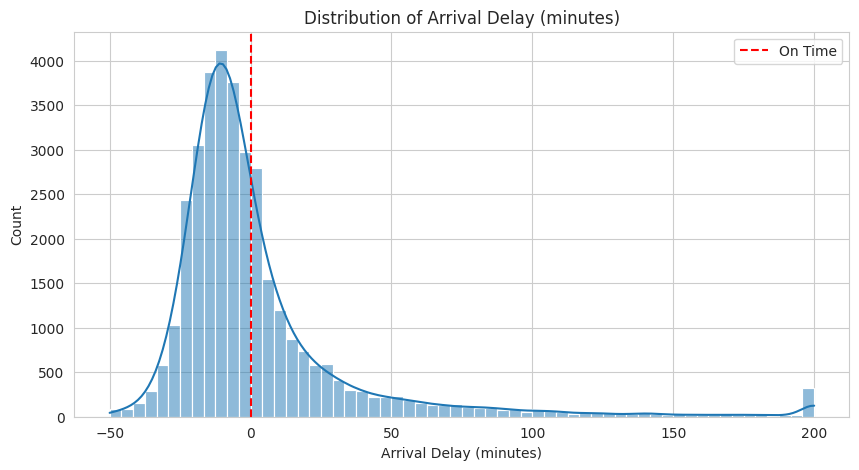

In [ ]:
plt.figure()
sns.histplot(df['ARR_DELAY'].clip(-50, 200), bins=60, kde=True)
# NOTE: .clip(-50,200) is ONLY for the chart's zoom - it does not alter
# the underlying data used in any calculation. Without it, extreme
# outliers (1000+ min delays) squash the whole chart into one spike near 0.
plt.title('Distribution of Arrival Delay (minutes)')
plt.xlabel('Arrival Delay (minutes)')
plt.axvline(0, color='red', linestyle='--', label='On Time')
plt.legend()
plt.show()

In [ ]:
# INTERPRETATION (for slide):
# Right-skewed distribution, peak just before 0 (~-10 min) - most flights
# arrive slightly early (airlines pad schedules). Long right tail = a
# minority of flights get badly delayed, pulling the MEAN well above the
# MEDIAN. The small bump at the 200 mark is a clipping artifact, not real data.

In [ ]:
# ---------- STEP 4: Cancellation Breakdown (Univariate) ----------
# Why: establishes the scale of disruption in absolute terms, even though
# the % is small.

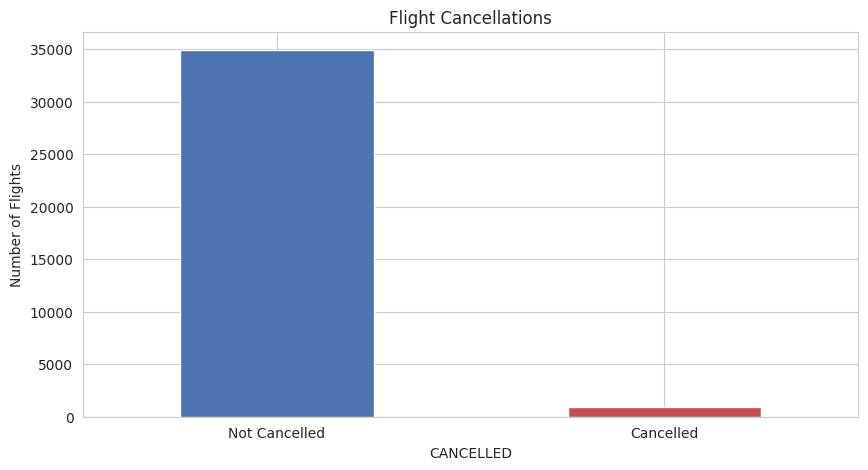

In [ ]:
plt.figure()
df['CANCELLED'].value_counts().plot(kind='bar', color=['#4C72B0','#C44E52'])
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'], rotation=0)
plt.title('Flight Cancellations')
plt.ylabel('Number of Flights')
plt.show()

In [ ]:
# INTERPRETATION: Only ~2.5% of flights cancelled, but at network scale
# this still represents thousands of disrupted passengers - not a "small"
# number when translated to real operational/customer impact.

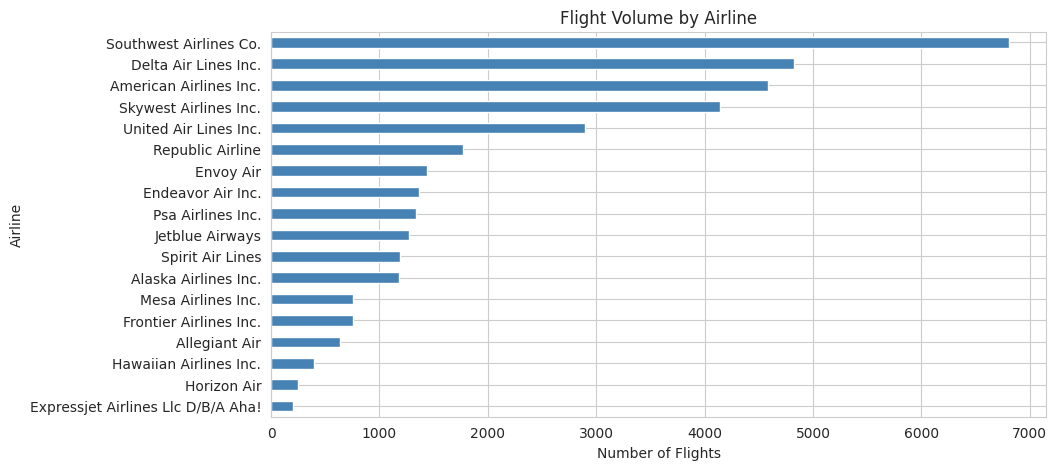

In [ ]:
# ---------- STEP 5: Flight Volume by Airline (Univariate) ----------
# Why: sets up sample-size context. An airline with only ~200 flights
# will have noisier delay averages than one with 6,800+ flights - we need
# to know this BEFORE ranking "best/worst" airlines later.
plt.figure()
df['AIRLINE'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Flight Volume by Airline')
plt.xlabel('Number of Flights')
plt.ylabel('Airline')
plt.gca().invert_yaxis()  # largest airline on top
plt.show()

In [ ]:
# INTERPRETATION: Southwest (6,809), Delta (4,821), American (4,581) lead
# volume. ExpressJet (205) is smallest but still above our ~200-flight
# reliability threshold, so all carriers remain usable for comparison.

In [ ]:
print(df['AIRLINE'].value_counts())

AIRLINE
Southwest Airlines Co.                6809
Delta Air Lines Inc.                  4821
American Airlines Inc.                4581
Skywest Airlines Inc.                 4145
United Air Lines Inc.                 2897
Republic Airline                      1770
Envoy Air                             1442
Endeavor Air Inc.                     1364
Psa Airlines Inc.                     1337
Jetblue Airways                       1269
Spirit Air Lines                      1190
Alaska Airlines Inc.                  1179
Mesa Airlines Inc.                     756
Frontier Airlines Inc.                 756
Allegiant Air                          635
Hawaiian Airlines Inc.                 393
Horizon Air                            250
Expressjet Airlines Llc D/B/A Aha!     205
Name: count, dtype: int64


/tmp/ipykernel_1068/2778008563.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='DELAY_SEVERITY_CAT', order=order, palette='viridis')


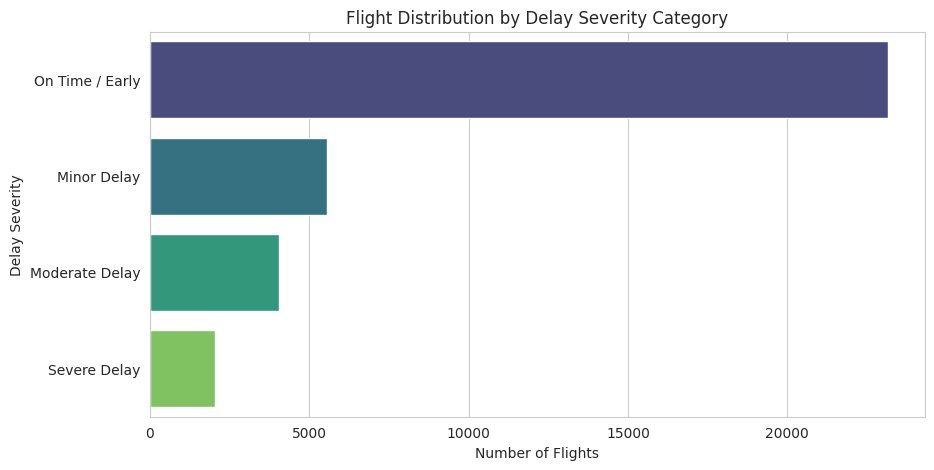

In [ ]:
#---------- STEP 6: Delay Severity Category (Univariate) ----------
# Why: DELAY_SEVERITY_CAT is a pre-built tier system - gives us a fast
# read on overall punctuality without computing our own bins.
plt.figure()
order = df['DELAY_SEVERITY_CAT'].value_counts().index
sns.countplot(data=df, y='DELAY_SEVERITY_CAT', order=order, palette='viridis')
plt.title('Flight Distribution by Delay Severity Category')
plt.xlabel('Number of Flights')
plt.ylabel('Delay Severity')
plt.show()

In [ ]:
# INTERPRETATION: 66.49% On Time/Early, but 5.89% fall into "Severe Delay"
# - this is the highest-priority slice for ops to target, since severe
# delays cause the most cascading/operational damage per flight.

In [ ]:
print((df['DELAY_SEVERITY_CAT'].value_counts(normalize=True) * 100).round(2))


DELAY_SEVERITY_CAT
On Time / Early    66.49
Minor Delay        15.96
Moderate Delay     11.67
Severe Delay        5.89
Name: proportion, dtype: float64


/tmp/ipykernel_1068/2824043089.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DAY_OF_WEEK', palette='mako')


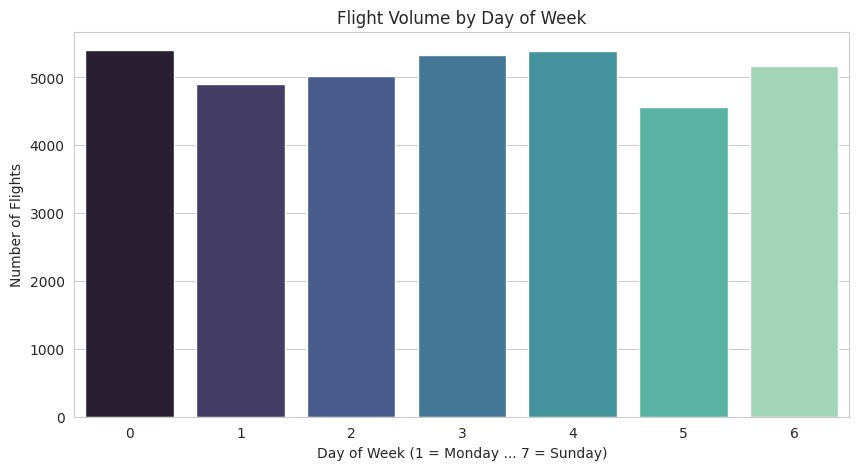

In [ ]:
# ---------- STEP 7: Flights by Day of Week (Univariate) ----------
# Why: sets up whether delay patterns later are driven by SCHEDULING
# VOLUME (busy days) vs something else (weather, carrier behavior).
plt.figure()
sns.countplot(data=df, x='DAY_OF_WEEK', palette='mako')
plt.title('Flight Volume by Day of Week')
plt.xlabel('Day of Week (1 = Monday ... 7 = Sunday)')
plt.ylabel('Number of Flights')
plt.show()

In [ ]:
# INTERPRETATION: Volume is stable Mon-Fri (~5,000-5,400 flights), with a
# ~15% dip on Saturday (day 5, 4,560 flights) - airlines run lighter
# schedules on the lowest-demand travel day.

In [ ]:
print(df['DAY_OF_WEEK'].value_counts().sort_index())

DAY_OF_WEEK
0    5403
1    4909
2    5025
3    5336
4    5391
5    4560
6    5175
Name: count, dtype: int64


BIVARIATE ANALYSIS - pairing variables against delay outcomes

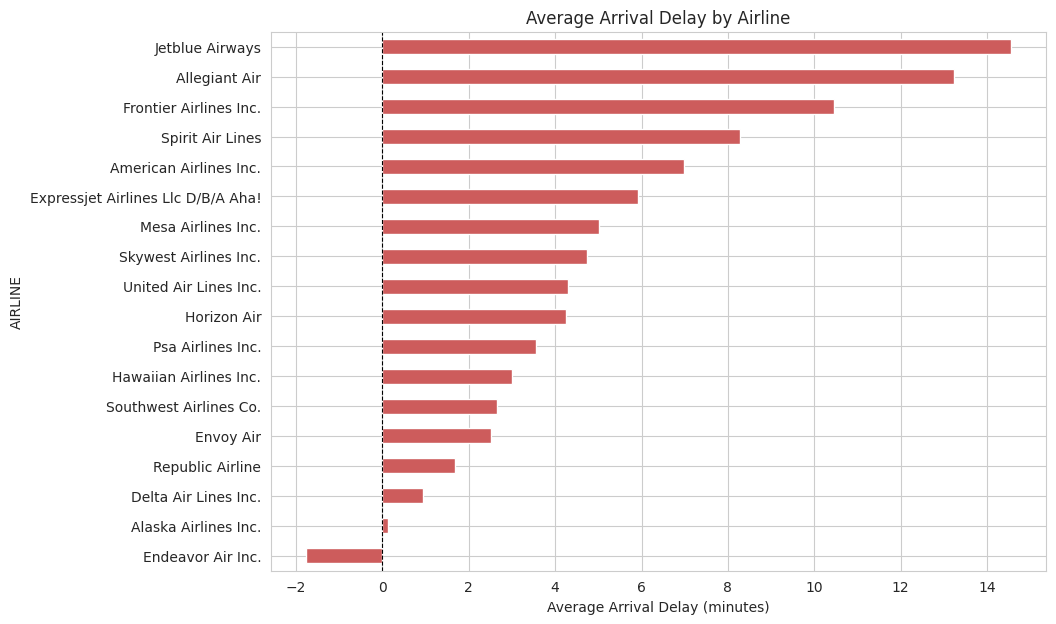

AIRLINE
Jetblue Airways                       14.55
Allegiant Air                         13.24
Frontier Airlines Inc.                10.47
Spirit Air Lines                       8.28
American Airlines Inc.                 6.98
Expressjet Airlines Llc D/B/A Aha!     5.93
Mesa Airlines Inc.                     5.00
Skywest Airlines Inc.                  4.74
United Air Lines Inc.                  4.29
Horizon Air                            4.26
Psa Airlines Inc.                      3.57
Hawaiian Airlines Inc.                 3.01
Southwest Airlines Co.                 2.66
Envoy Air                              2.52
Republic Airline                       1.67
Delta Air Lines Inc.                   0.94
Alaska Airlines Inc.                   0.14
Endeavor Air Inc.                     -1.76
Name: ARR_DELAY, dtype: float64


In [ ]:
# ---------- STEP 8: Average Delay by Airline (Bivariate) ----------
# Why: directly answers the PS requirement to identify "worst-performing
# carriers."
avg_delay_airline = df.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,7))
avg_delay_airline.plot(kind='barh', color='indianred')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Average Arrival Delay (minutes)')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.gca().invert_yaxis()
plt.show()

print(avg_delay_airline.round(2))

In [ ]:
# INTERPRETATION: JetBlue (14.55 min), Allegiant (13.24), Frontier (10.47)
# worst - notably all budget/leisure carriers, possibly tighter turnaround
# buffers. Endeavor Air actually runs early on average (-1.76 min). CAVEAT:
# cross-reference with Step 5 volumes - low-sample carriers (e.g. ExpressJet,
# 205 flights) are less statistically reliable than Delta (4,821 flights).

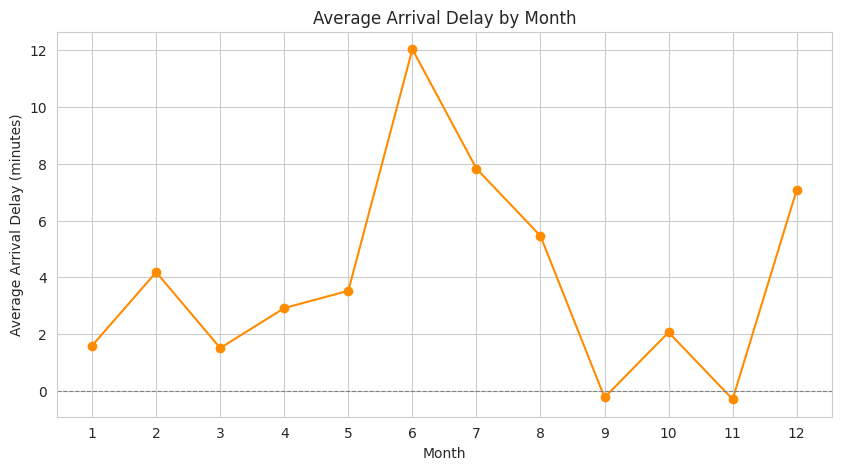

MONTH
1      1.60
2      4.18
3      1.52
4      2.92
5      3.53
6     12.02
7      7.83
8      5.46
9     -0.22
10     2.07
11    -0.28
12     7.07
Name: ARR_DELAY, dtype: float64


In [ ]:
# ---------- STEP 9: Average Delay by Month (Seasonality) ----------
# Why: directly answers PS requirement for "seasonal/weather-driven
# disruption patterns."
avg_delay_month = df.groupby('MONTH')['ARR_DELAY'].mean()

plt.figure()
avg_delay_month.plot(kind='line', marker='o', color='darkorange')
plt.title('Average Arrival Delay by Month')
plt.xlabel('Month')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(range(1,13))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

print(avg_delay_month.round(2))
# INTERPRETATION: Sharp peak in June (12.02 min) continuing through July
# (7.83) - summer thunderstorm season + peak leisure travel. December also
# elevated (7.07) - winter weather + holiday volume. Sept/Nov run at or
# below zero - the seasonal lull between summer and holiday peaks.
# TAKEAWAY FOR RECOMMENDATIONS: widen scheduling buffers June-August.

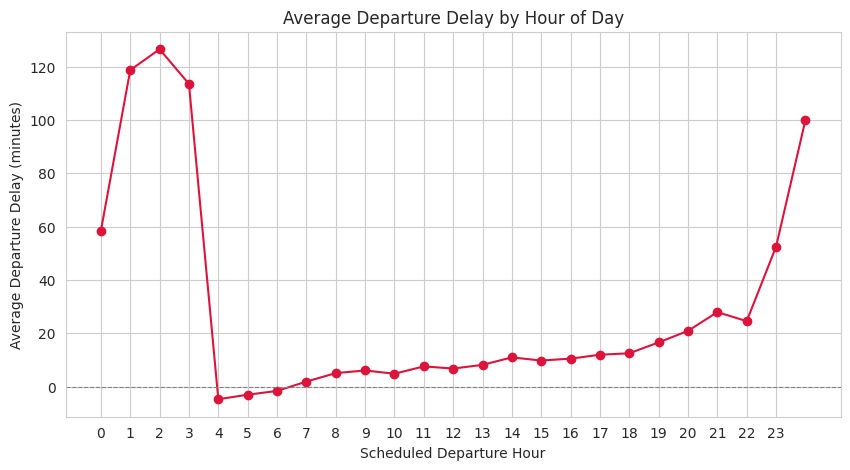

DEP_HOUR
0.0      58.46
1.0     118.71
2.0     126.54
3.0     113.55
4.0      -4.70
5.0      -3.01
6.0      -1.58
7.0       1.91
8.0       5.09
9.0       6.09
10.0      4.86
11.0      7.61
12.0      6.80
13.0      8.18
14.0     10.99
15.0      9.80
16.0     10.52
17.0     11.98
18.0     12.53
19.0     16.61
20.0     20.93
21.0     27.96
22.0     24.57
23.0     52.50
24.0    100.00
Name: DEP_DELAY, dtype: float64


In [ ]:
# ---------- STEP 10: Average Delay by Hour of Day (Peak Periods) ----------
# Why: directly answers PS requirement for "peak delay periods."
avg_delay_hour = df.groupby('DEP_HOUR')['DEP_DELAY'].mean()

plt.figure()
avg_delay_hour.plot(kind='line', marker='o', color='crimson')
plt.title('Average Departure Delay by Hour of Day')
plt.xlabel('Scheduled Departure Hour')
plt.ylabel('Average Departure Delay (minutes)')
plt.xticks(range(0,24))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

print(avg_delay_hour.round(2))
''' INTERPRETATION: Departure delay shows a clear cascading pattern
through the day: early morning flights (4-6 AM) depart on time or early, since
there's no upstream delay to inherit. Delay builds steadily as the day
progresses, peaking sharply in late evening (20:00-23:00), consistent with the
late-aircraft effect where a single aircraft's morning delay compounds across
 its later flights. Very early hour buckets (0-3 AM) show extreme but unreliable
  averages due to low flight volume and should be interpreted with caution.'''

In [ ]:
print(df['DEP_HOUR'].value_counts().sort_index())

DEP_HOUR
0.0      151
1.0       41
2.0       24
3.0       11
4.0       70
5.0     1346
6.0     2253
7.0     2077
8.0     2216
9.0     2061
10.0    2175
11.0    2174
12.0    2128
13.0    2071
14.0    2017
15.0    2045
16.0    1993
17.0    2150
18.0    2017
19.0    1834
20.0    1659
21.0    1149
22.0     871
23.0     377
24.0       4
Name: count, dtype: int64


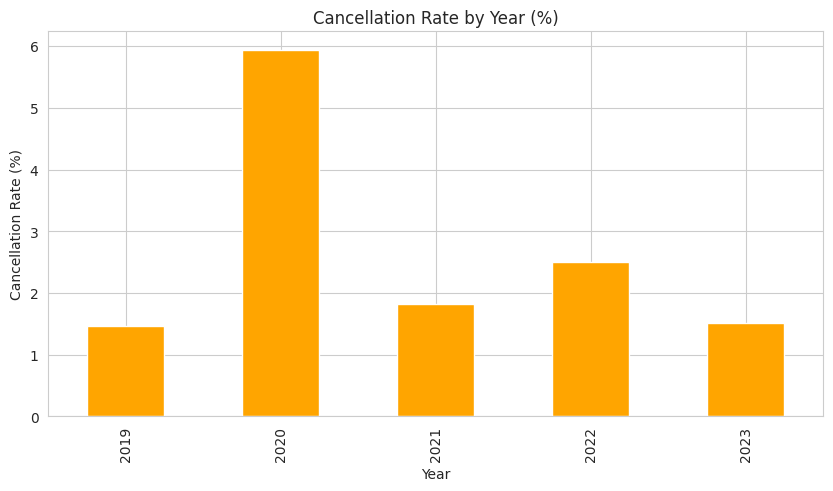

YEAR
2019    1.46
2020    5.94
2021    1.83
2022    2.51
2023    1.51
Name: CANCELLED, dtype: float64


In [ ]:
#Step 11: Cancellation Rate by Year
# Why: checks cancellation trend 2019-2023 - this span includes COVID-19,
# so we expect a dramatic anomaly in 2020 that isn't a "data quality issue"
# but a real, explainable business event.
cancel_by_year = df.groupby('YEAR')['CANCELLED'].mean() * 100

plt.figure()
cancel_by_year.plot(kind='bar', color='orange')
plt.title('Cancellation Rate by Year (%)')
plt.xlabel('Year')
plt.ylabel('Cancellation Rate (%)')
plt.show()
print(cancel_by_year.round(2))

In [ ]:
'''Insight: Cancellation rate remained stable across 2019, 2021, 2022, and 2023 (1.46%-2.51%),
 but spiked to 5.94% in 2020 - nearly 4x the baseline - driven by COVID-19 travel restrictions
  and demand collapse. This is a real, well-understood external shock rather than a data
  quality issue, and analysts should be cautious about treating 2020 as representative when
  calculating multi-year baseline KPIs (e.g. a straight 2019-2023 average would understate
  normal-year performance).'''

'Insight: Cancellation rate remained stable across 2019, 2021, 2022, and 2023 (1.46%-2.51%),\n but spiked to 5.94% in 2020 - nearly 4x the baseline - driven by COVID-19 travel restrictions\n  and demand collapse. This is a real, well-understood external shock rather than a data \n  quality issue, and analysts should be cautious about treating 2020 as representative when \n  calculating multi-year baseline KPIs (e.g. a straight 2019-2023 average would understate \n  normal-year performance).'

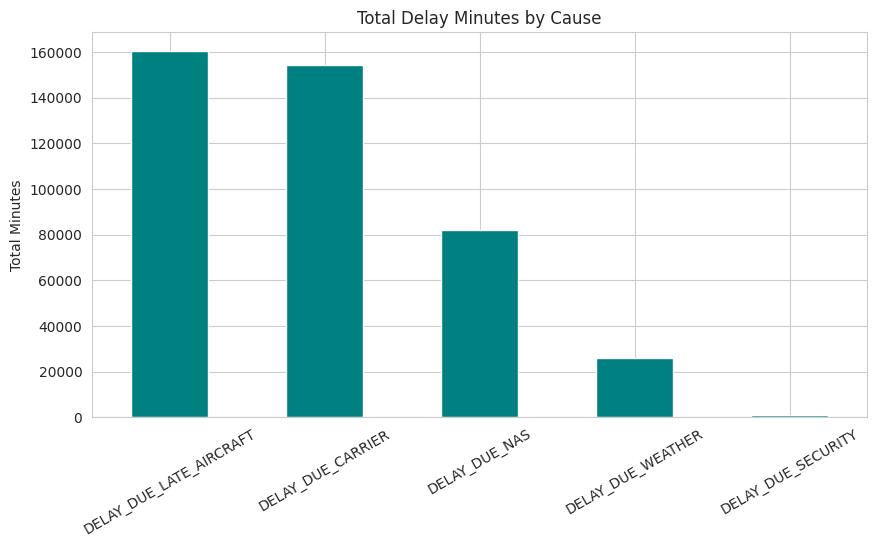

DELAY_DUE_LATE_AIRCRAFT    160684.0
DELAY_DUE_CARRIER          154307.0
DELAY_DUE_NAS               82242.0
DELAY_DUE_WEATHER           25783.0
DELAY_DUE_SECURITY            844.0
dtype: float64
DELAY_DUE_LATE_AIRCRAFT    37.91
DELAY_DUE_CARRIER          36.41
DELAY_DUE_NAS              19.40
DELAY_DUE_WEATHER           6.08
DELAY_DUE_SECURITY          0.20
dtype: float64


In [ ]:
#Step 12: Delay Reason Breakdown (Carrier / Weather / NAS / Security / Late Aircraft)
# Why: these 5 columns only have values when a flight is actually delayed
# (recall ~82% missing from our earlier data understanding). Summing them
# tells us which cause contributes the most total delay-minutes across
# the whole network - the biggest lever for the ops team to pull.
delay_causes = df[['DELAY_DUE_CARRIER', 'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS',
                    'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT']].sum().sort_values(ascending=False)

plt.figure()
delay_causes.plot(kind='bar', color='teal')
plt.title('Total Delay Minutes by Cause')
plt.ylabel('Total Minutes')
plt.xticks(rotation=30)
plt.show()
print(delay_causes)

# Also useful: what % share each cause represents
print((delay_causes / delay_causes.sum() * 100).round(2))

In [ ]:
''' Insight: Late-aircraft delay (37.91%) and carrier-caused delay (36.41%) together account
for nearly three-quarters of all delay minutes in the network, while weather (6.08%)
and security (0.20%) contribute minimally. This is a critical finding: the majority of delay
is operationally controllable rather than externally imposed, meaning targeted fixes to
turnaround processes and carrier-level operations would have far greater impact on network
punctuality than any weather-mitigation strategy.'''

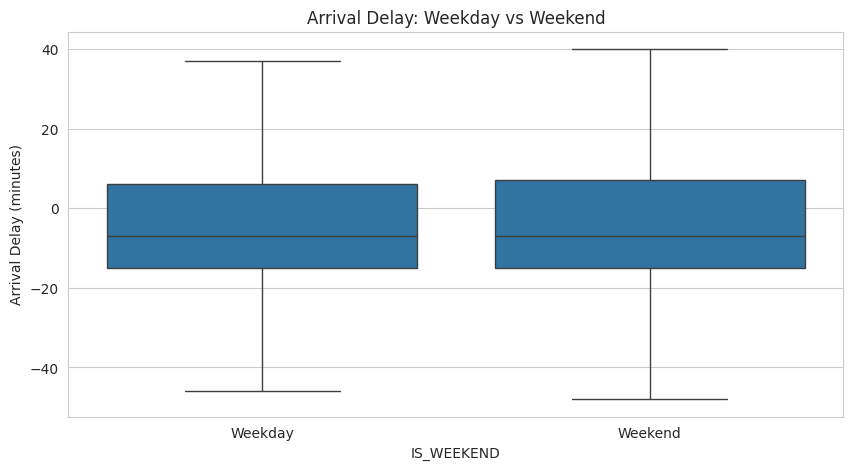

IS_WEEKEND
0    3.74
1    5.14
Name: ARR_DELAY, dtype: float64
IS_WEEKEND
0   -7.0
1   -7.0
Name: ARR_DELAY, dtype: float64


In [ ]:
#Step 13: Weekend vs Weekday Delay
# Why: tests whether leisure-heavy weekend travel behaves differently
# from weekday (business-heavy) travel - relevant for staffing/scheduling
# decisions.
plt.figure()
sns.boxplot(data=df, x='IS_WEEKEND', y='ARR_DELAY', showfliers=False)
# showfliers=False hides extreme outlier dots so the box (where most data
# actually sits) is readable - outliers are already covered by Step 3's
# histogram, no need to repeat them here.
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title('Arrival Delay: Weekday vs Weekend')
plt.ylabel('Arrival Delay (minutes)')
plt.show()

print(df.groupby('IS_WEEKEND')['ARR_DELAY'].mean().round(2))
print(df.groupby('IS_WEEKEND')['ARR_DELAY'].median().round(2))

In [ ]:
''' Insight: Median arrival delay is identical for weekdays and weekends (-7 minutes), indicating
a typical flight's punctuality doesn't depend on day type. However, the mean is
meaningfully higher on weekends (5.14 vs 3.74 minutes), suggesting weekend travel
includes a slightly heavier tail of severe delays - possibly linked to leisure travel
volume spikes or reduced weekend staffing/support resources - rather than a shift in
overall on-time performance.'''

         avg_delay  cancel_rate  flights
ROUTE                                   
DFW-LAX      42.40         2.08       48
ATL-DFW      40.74         0.00       32
BOS-ORD      34.24         0.00       34
SLC-LAX      30.74         3.12       32
ORD-BNA      28.94         3.12       32
MIA-JFK      24.44         2.86       35
MCO-PHL      23.71         9.68       31
DCA-LGA      22.20         0.00       31
SEA-LAX      21.55         0.00       40
SEA-LAS      19.34         0.00       41
MIA-ATL      18.48         0.00       31
LGA-DFW      18.18         8.33       36
PHX-LAX      17.03         0.00       32
DEN-LAS      16.21        10.81       37
MIA-LGA      15.03         2.70       37


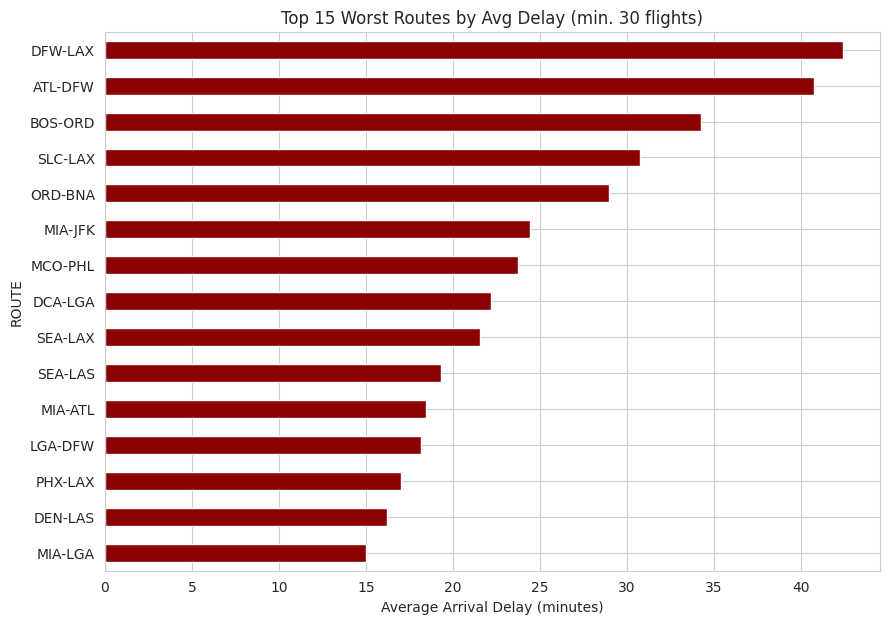

In [ ]:
#Step 14: Worst-Performing Routes (Multivariate — Delay + Cancellation Together)
# Why: a route can look bad on delay alone, or bad on cancellation alone -
# combining both plus flight volume gives ops a genuinely prioritized list,
# not a one-dimensional ranking. .query('flights > 100') filters out
# low-volume routes so we don't rank a route with 3 total flights as
# "worst" off pure noise.
route_stats = df.groupby('ROUTE').agg(
    avg_delay=('ARR_DELAY', 'mean'),
    cancel_rate=('CANCELLED', 'mean'),
    flights=('ROUTE', 'count')
).query('flights > 30').sort_values('avg_delay', ascending=False).head(15)

route_stats['cancel_rate'] = (route_stats['cancel_rate'] * 100).round(2)
route_stats['avg_delay'] = route_stats['avg_delay'].round(2)

print(route_stats)

plt.figure(figsize=(10, 7))
route_stats['avg_delay'].plot(kind='barh', color='darkred')
plt.title('Top 15 Worst Routes by Avg Delay (min. 30 flights)')
plt.xlabel('Average Arrival Delay (minutes)')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
''' Insight: DFW-LAX shows the highest average delay (42.40 min) among routes with sufficient sample size,
 likely reflecting congestion at major hub airports. Notably, delay and cancellation don't
 always move together: several high-delay routes (ATL-DFW, BOS-ORD, DCA-LGA) show 0% cancellations,
  indicating chronic but reliable lateness, while routes like DEN-LAS and MCO-PHL combine moderate
delay with disproportionately high cancellation rates (10.81% and 9.68%), pointing to a deeper
operational reliability issue rather than simple scheduling tightness.'''

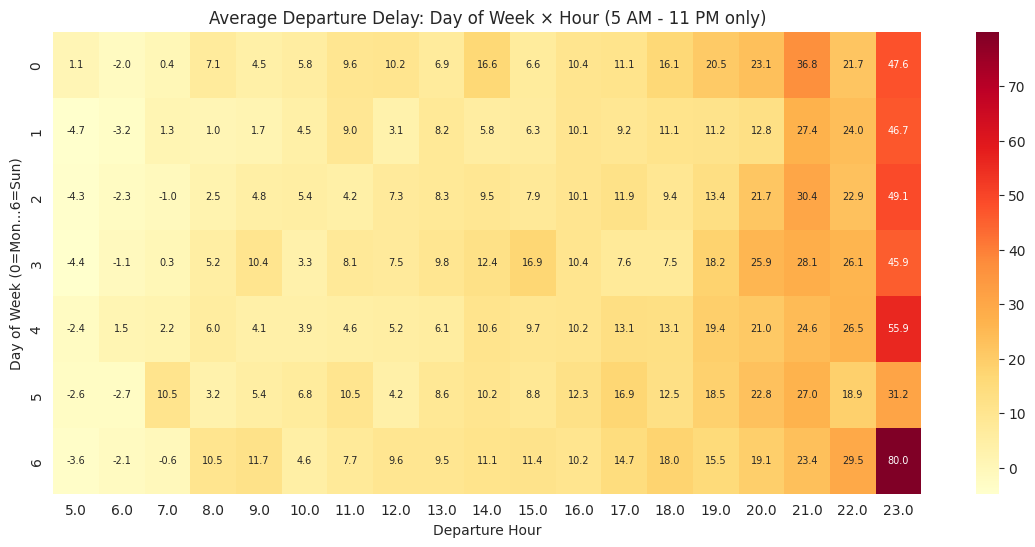

In [ ]:
#Step 15: Day-of-Week × Hour Heatmap
# Why: a heatmap lets us see interaction effects a single groupby can't -
# e.g. "Friday evenings" might be worse than either Friday or evenings
# alone would suggest.
# Why: hours 0-4 and 24 have <150 flights each (vs 1,600-2,200+ for
# daytime), so their averages are unreliable and drown out real patterns.
# We exclude them here rather than let one noisy cell distort the whole map.
df_daytime = df[(df['DEP_HOUR'] >= 5) & (df['DEP_HOUR'] <= 23)]

pivot = df_daytime.pivot_table(values='DEP_DELAY', index='DAY_OF_WEEK', columns='DEP_HOUR', aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f', annot_kws={'size': 7})
plt.title('Average Departure Delay: Day of Week × Hour (5 AM - 11 PM only)')
plt.xlabel('Departure Hour')
plt.ylabel('Day of Week (0=Mon...6=Sun)')
plt.show()

In [ ]:
print(df[(df['DAY_OF_WEEK']==6) & (df['DEP_HOUR']==23)].shape[0])


70


In [ ]:
'''Insight: The day-of-week × hour heatmap confirms the late-aircraft cascade effect
holds consistently across all seven days: delays start near zero or negative in early
morning (5-7 AM) and climb steadily through the day, accelerating sharply after 7 PM and
peaking at 11 PM on every single day. This rules out the possibility that Step 10's
aggregate pattern was driven by just one or two unusual days — it's a structural,
network-wide scheduling issue, not a day-specific anomaly. [If the Sunday 23:00 cell
 has a low flight count, add:] The Sunday 23:00 cell shows a notably higher spike (80.0 min)
  than other days, but this should be treated cautiously given the smaller sample
  size at that specific hour.'''

"Insight: The day-of-week × hour heatmap confirms the late-aircraft cascade effect \nholds consistently across all seven days: delays start near zero or negative in early \nmorning (5-7 AM) and climb steadily through the day, accelerating sharply after 7 PM and \npeaking at 11 PM on every single day. This rules out the possibility that Step 10's \naggregate pattern was driven by just one or two unusual days — it's a structural, \nnetwork-wide scheduling issue, not a day-specific anomaly. [If the Sunday 23:00 cell\n has a low flight count, add:] The Sunday 23:00 cell shows a notably higher spike (80.0 min)\n  than other days, but this should be treated cautiously given the smaller sample \n  size at that specific hour."

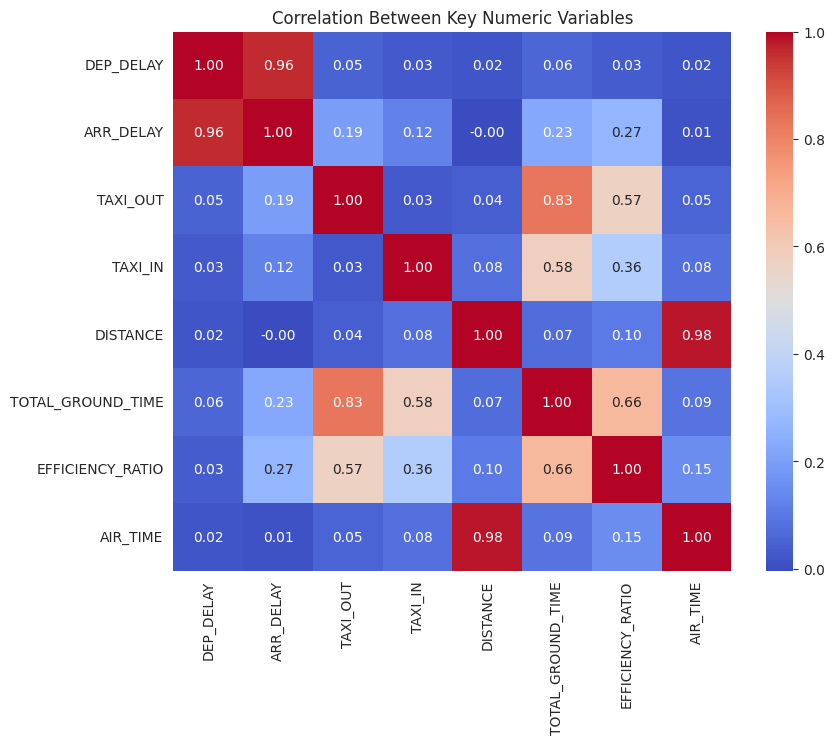

In [ ]:
# Why: quantifies relationships between operational metrics - e.g. does
# longer taxi time correlate with longer delay? Does distance matter?
# This backs up "correlation" as a required statistical summary in the doc.
num_cols = ['DEP_DELAY', 'ARR_DELAY', 'TAXI_OUT', 'TAXI_IN', 'DISTANCE',
            'TOTAL_GROUND_TIME', 'EFFICIENCY_RATIO', 'AIR_TIME']

plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Key Numeric Variables')
plt.show()

In [ ]:
''' Insight: Departure and arrival delay are almost perfectly correlated (0.96), confirming
that fixing departure punctuality is the most direct lever for improving arrival performance.
 Notably, flight distance shows virtually no correlation with arrival delay (-0.00),
 ruling out route length as a delay driver — this reinforces the Section 5 finding that
 late-aircraft and carrier-caused delays (operational/scheduling factors), not flight
 characteristics like distance, are the primary drivers of network delay.'''